<a href="https://colab.research.google.com/github/nooramariyam/Cyber-Threat-Detection/blob/main/Cyber_Threat_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Done")

Done


In [3]:
import os
print(os.listdir("dataset"))

['4_malicious_ips.csv', '1_otx_threat_intel.csv', '3_malicious_domains.csv', '2_cve_vulnerabilities.csv']


In [4]:
import pandas as pd

df = pd.read_csv("dataset/4_malicious_ips.csv")

print(df.head())

               IP Country Continent      ASN                      Owner  \
0   176.10.99.200      CH        EU  51395.0              Datasource AG   
1   176.10.99.201      CH        EU  51395.0              Datasource AG   
2  77.247.181.162      NL        EU  43350.0  NForce Entertainment B.V.   
3  77.247.181.163      NL        EU  43350.0  NForce Entertainment B.V.   
4  199.87.154.255      CA   Unknown  18451.0                    LES.NET   

           Network  Malicious_Votes  Suspicious_Votes  Harmless_Votes  \
0   176.10.96.0/19                3                 0              55   
1   176.10.96.0/19                0                 1              53   
2  77.247.176.0/21                4                 1              53   
3  77.247.176.0/21                2                 2              55   
4  199.87.152.0/21                2                 0              54   

   Undetected_Votes  Total_Reports  Reputation_Score Threat_Label  \
0                33             91       

In [5]:
df1 = pd.read_csv("dataset/1_otx_threat_intel.csv")

print(df1.head())

                   Pulse_ID  \
0  69f1e236e4e192f639298d53   
1  69f1de85544538ce8b03332a   
2  69f1d20216d6091f01f8a6eb   
3  69f1d26f3c7a8e098eccb448   
4  69f1d2d45ec26fc5e1ca72f4   

                                               Title  \
0       Multi-Stage Malware Execution Chain Analysis   
1  User interaction with a ClickFix-style phishin...   
2  Kyber ransomware is not just post-quantum name...   
3         Rebex-based Telegram RAT Targeting Vietnam   
4  KYCShadow: An Android Banking Malware Exploiti...   

                                         Description      Author  \
0  A sophisticated multi-stage malware execution ...  AlienVault   
1  A ClickFix-style phishing campaign leveraged s...  AlienVault   
2  A detailed technical analysis confirms that Ky...  AlienVault   
3  A sophisticated CHM-based malware campaign has...  AlienVault   
4  An Android malware campaign masquerading as a ...  AlienVault   

                      Created                    Modified    TLP  \

In [6]:
df2 = pd.read_csv("dataset/2_cve_vulnerabilities.csv")

print(df2.head())

            cveID vendorProject             product  \
0   CVE-2024-1708   ConnectWise       ScreenConnect   
1  CVE-2026-32202     Microsoft             Windows   
2  CVE-2025-29635        D-Link            DIR-823X   
3   CVE-2024-7399       Samsung  MagicINFO 9 Server   
4  CVE-2024-57728   SimpleHelp           SimpleHelp   

                                   vulnerabilityName   dateAdded  \
0  ConnectWise ScreenConnect Path Traversal Vulne...  2026-04-28   
1  Microsoft Windows Protection Mechanism Failure...  2026-04-28   
2    D-Link DIR-823X Command Injection Vulnerability  2026-04-24   
3  Samsung MagicINFO 9 Server Path Traversal Vuln...  2026-04-24   
4            SimpleHelp Path Traversal Vulnerability  2026-04-24   

                                    shortDescription  \
0  ConnectWise ScreenConnect contains a path trav...   
1  Microsoft Windows Shell contains a protection ...   
2  D-Link DIR-823X contains a command injection v...   
3  Samsung MagicINFO 9 Server contai

In [7]:
df3 = pd.read_csv("dataset/3_malicious_domains.csv")

print(df3.head())

                  Domain TLD  Domain_Length Has_Numbers Has_Hyphen Registrar  \
0       urlhaus.abuse.ch  ch             16          No         No   Unknown   
1        bazaar.abuse.ch  ch             15          No         No   Unknown   
2  feodotracker.abuse.ch  ch             21          No         No   Unknown   
3         sslbl.abuse.ch  ch             14          No         No   Unknown   
4     threatfox.abuse.ch  ch             18          No         No   Unknown   

  Creation_Date Last_Update_Date  Reputation  Malicious_Votes  \
0       Unknown          Unknown           2                0   
1       Unknown          Unknown           6                1   
2       Unknown          Unknown           1                0   
3       Unknown          Unknown           0                0   
4       Unknown          Unknown           0                0   

   Suspicious_Votes  Harmless_Votes  Undetected_Votes  Total_Engines  \
0                 0              59                32   

In [8]:
print(df.columns)

Index(['IP', 'Country', 'Continent', 'ASN', 'Owner', 'Network',
       'Malicious_Votes', 'Suspicious_Votes', 'Harmless_Votes',
       'Undetected_Votes', 'Total_Reports', 'Reputation_Score', 'Threat_Label',
       'Threat_Category', 'Regional_Registry', 'WHOIS_Summary', 'TOR_Node',
       'Times_Submitted', 'Last_Analysis_Date', 'Threat_Severity'],
      dtype='object')


R2 Score: 0.1558839334029497
MAE Score: 1.954758268818803


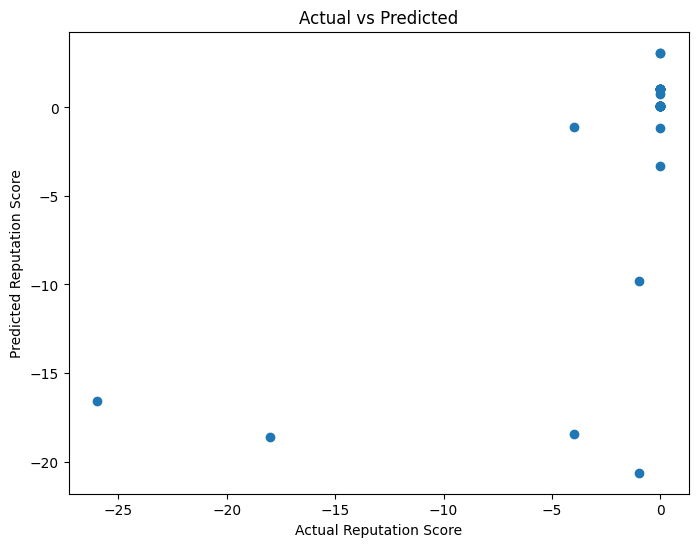

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load dataset
df = pd.read_csv("dataset/4_malicious_ips.csv")

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Select useful columns
X = df[[
    'Malicious_Votes',
    'Suspicious_Votes',
    'Harmless_Votes',
    'Undetected_Votes',
    'Total_Reports'
]]

# Target column
y = df['Reputation_Score']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Scores
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE Score:", mean_absolute_error(y_test, y_pred))

# Graph
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Reputation Score")
plt.ylabel("Predicted Reputation Score")
plt.title("Actual vs Predicted")

# Save graph
plt.savefig("prediction_graph.png")

plt.show()

# Download graph
from google.colab import files
files.download("prediction_graph.png")

R2 Score: 1.0
MAE Score: 0.0


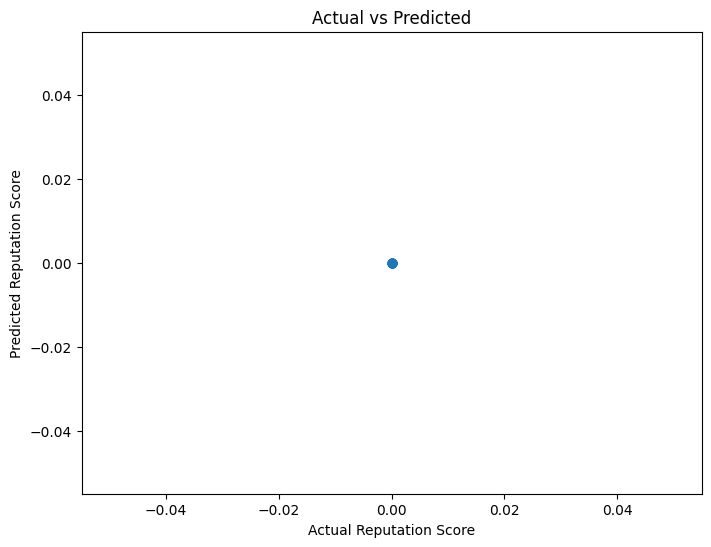

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("dataset/4_malicious_ips.csv")

# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Select useful columns
columns = [
    'Malicious_Votes',
    'Suspicious_Votes',
    'Harmless_Votes',
    'Undetected_Votes',
    'Total_Reports',
    'Reputation_Score'
]

df = df[columns]

# Remove outliers using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Features and target
X = df.drop(columns=['Reputation_Score'])
y = df['Reputation_Score']

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Better ML model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Scores
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE Score:", mae)

# Graph
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Reputation Score")
plt.ylabel("Predicted Reputation Score")
plt.title("Actual vs Predicted")

# Save graph
plt.savefig("clean_prediction_graph.png")

plt.show()

# Download graph
from google.colab import files
files.download("clean_prediction_graph.png")